# Parameterized laser trigger visualization

This notebook visualizes the current digital laser trigger generator used when `demo.py` runs with `--trigger-source laser`.

Important: this is a digital-domain simulator. The constants `k1..k4` are not camera-calibrated physical constants unless you explicitly calibrate them; here they should be treated as simulation hyperparameters.

In [26]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from src.color_stripe.laser_trigger import (
    LaserCalibration,
    LaserParams,
    _intensity_bounds,
    build_laser_param_grid,
    generate_laser_trigger_tensor,
)

plt.rcParams["figure.dpi"] = 120
device = "cpu"

## Helper functions

The generator returns tensors in the training format `[N, 3, H, W]` with pixel scale `0..255`. The helpers below convert them to displayable RGB images.

In [37]:
def to_image(trigger):
    """Convert one generated trigger tensor [3,H,W] in 0..255 to [H,W,3] in 0..1."""
    return (trigger.detach().cpu().clamp(0, 255) / 255.0).permute(1, 2, 0)


def make_trigger(
    params,
    *,
    isdetector=False,
    model="linear",
    color="green",
    trigger_height=50,
    trigger_width=None,
    position=0.5,
    calibration=LaserCalibration(),
    noise_std=0.0,
):
    return generate_laser_trigger_tensor(
        [params],
        isdetector=isdetector,
        model=model,
        color=color,
        trigger_height=trigger_height,
        trigger_width=trigger_width,
        position=position,
        calibration=calibration,
        noise_std=noise_std,
        device=device,
    )[0]


def show_grid(items, cols=4, figsize=(12, 6)):
    rows = (len(items) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows == 1:
        axes = [axes] if cols == 1 else axes
    axes = list(torch.tensor([], dtype=torch.float32).numpy()) if len(items) == 0 else axes.ravel()
    for ax, (img, title) in zip(axes, items):
        ax.imshow(img)
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    for ax in axes[len(items):]:
        ax.axis("off")
    plt.tight_layout()
    return fig


def summarize(trigger, params=None, calibration=LaserCalibration()):
    x = trigger.detach().cpu() / 255.0
    parts = [f"min={x.min():.3f}", f"mean={x.mean():.3f}", f"max={x.max():.3f}"]
    if params is not None:
        imin, imax = _intensity_bounds(params, calibration)
        parts.extend([f"\nImin={imin:.3f}", f"Imax={imax:.3f}"])
    return ", ".join(parts)

## Single baseline trigger

Default-like TA-C trigger: green, linear profile, centered stripe, 224x224 image, 50-pixel stripe height.

In [38]:
model_name = "gaussian"

Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])


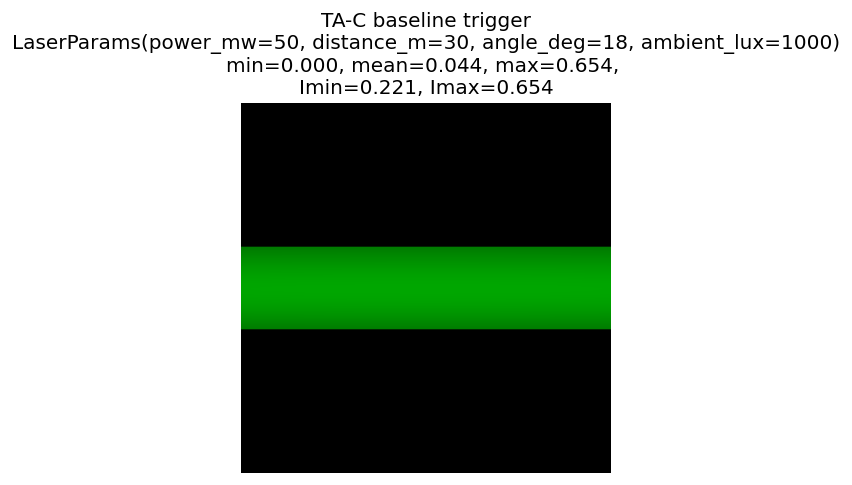

In [44]:
base = LaserParams(power_mw=50, distance_m=30, angle_deg=18, ambient_lux=1000)
trigger = make_trigger(base, isdetector=False, model=model_name, color="green", trigger_height=50)

plt.figure(figsize=(4, 4))
plt.imshow(to_image(trigger))
plt.title(f"TA-C baseline trigger\n{base}\n{summarize(trigger, base)}")
plt.axis("off");

## Profile shape comparison

`linear`, `sigmoid`, and `gaussian` share the same parameter-derived intensity bounds but distribute the intensity differently in the stripe.

Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])


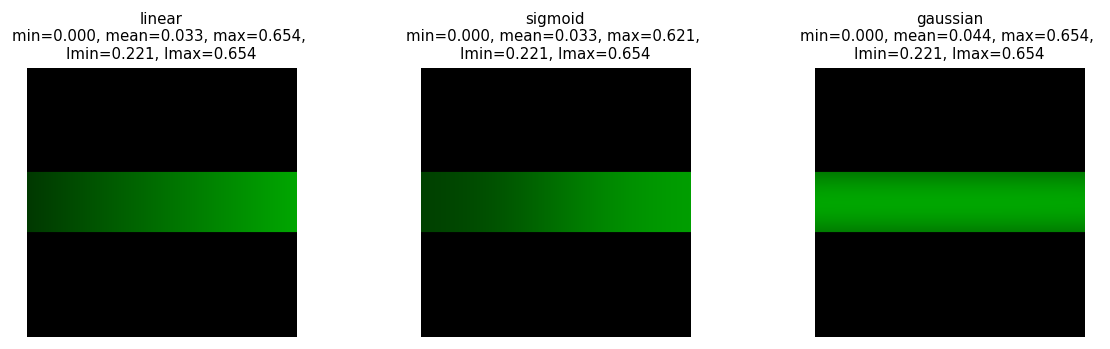

In [45]:
items = []
for model in ["linear", "sigmoid", "gaussian"]:
    t = make_trigger(base, isdetector=False, model=model, color="green", trigger_height=50)
    items.append((to_image(t), f"{model}\n{summarize(t, base)}"))
show_grid(items, cols=3, figsize=(10, 3));

## Power sweep

Increasing `power_mw` increases the laser term. With large values the generated stripe may saturate after clamping.

Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])


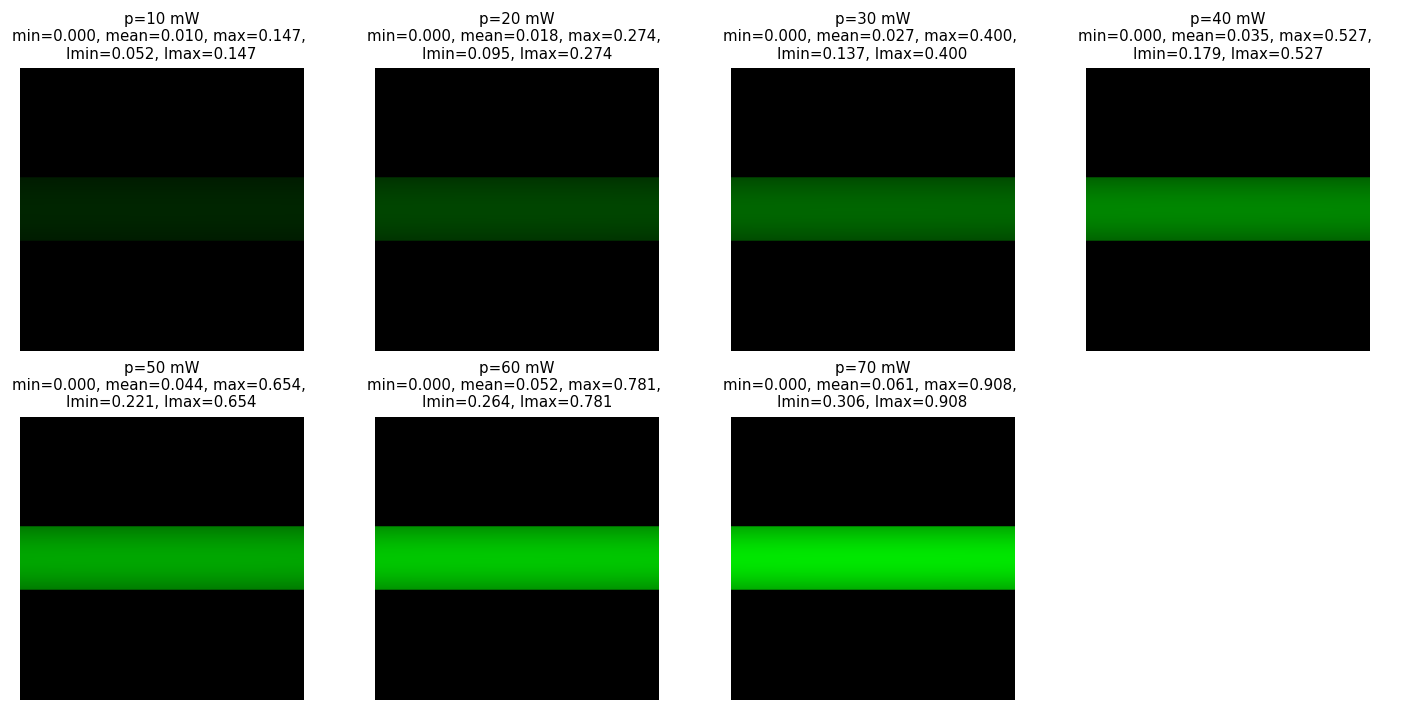

In [46]:
items = []
for p in [10, 20, 30, 40, 50, 60, 70]:
    params = LaserParams(power_mw=p, distance_m=30, angle_deg=18, ambient_lux=1000)
    t = make_trigger(params, isdetector=False, model=model_name, color="green", trigger_height=50)
    items.append((to_image(t), f"p={p} mW\n{summarize(t, params)}"))
show_grid(items, cols=4, figsize=(12, 6));

## Distance and angle sweep

Distance uses inverse-square attenuation. Angle uses `max(cos(theta), 0)`. Negative angles reverse the horizontal profile direction.

Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])


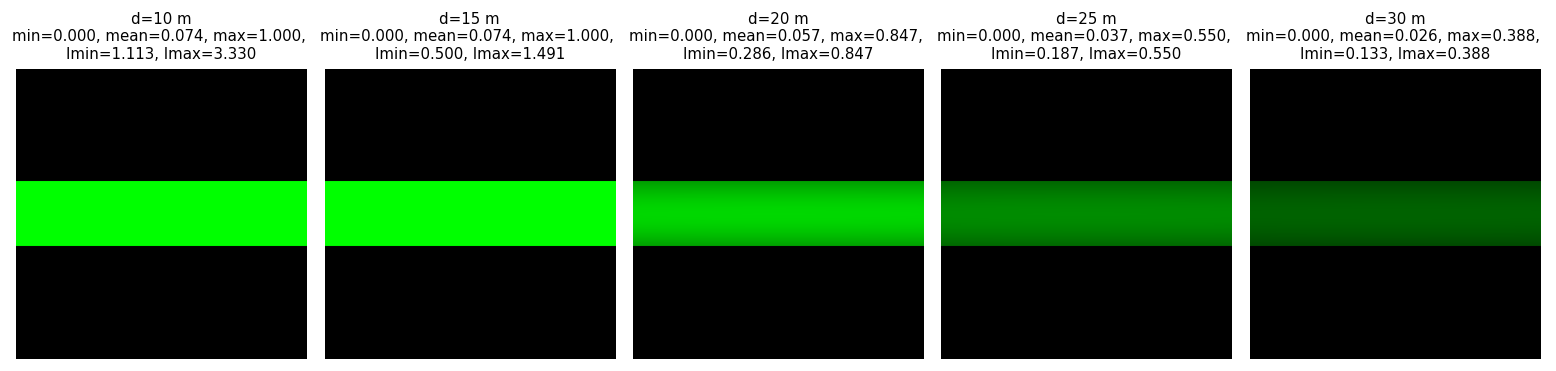

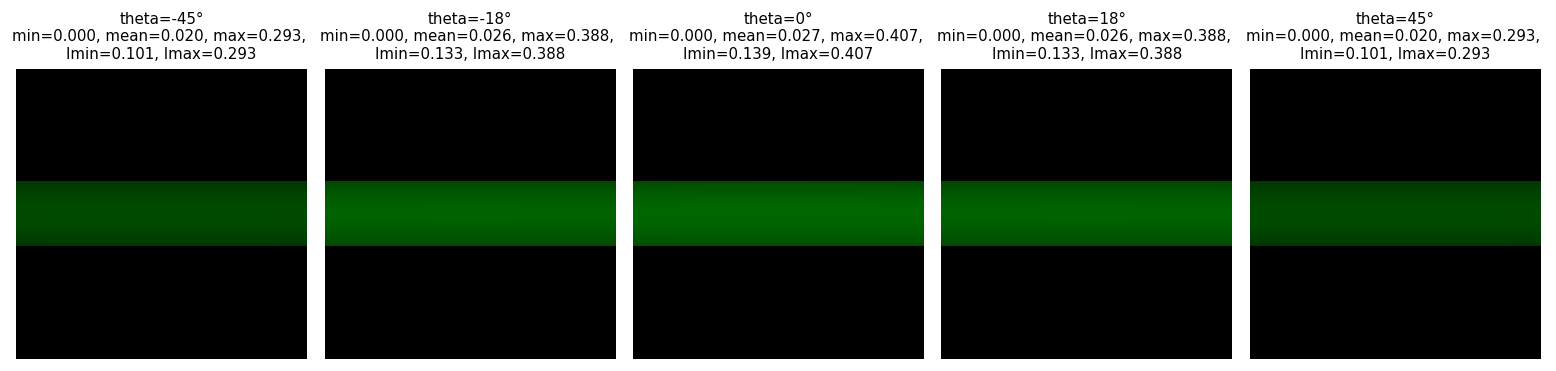

In [47]:
items = []
for d in [10, 15, 20, 25, 30]:
    params = LaserParams(power_mw=29, distance_m=d, angle_deg=18, ambient_lux=1000)
    t = make_trigger(params, isdetector=False, model=model_name, color="green", trigger_height=50)
    items.append((to_image(t), f"d={d} m\n{summarize(t, params)}"))
show_grid(items, cols=5, figsize=(13, 3));

items = []
for angle in [-45, -18, 0, 18, 45]:
    params = LaserParams(power_mw=29, distance_m=30, angle_deg=angle, ambient_lux=1000)
    t = make_trigger(params, isdetector=False, model=model_name, color="green", trigger_height=50)
    items.append((to_image(t), f"theta={angle}°\n{summarize(t, params)}"))
show_grid(items, cols=5, figsize=(13, 3));

## Color, position, width, and noise

These are non-physical controls in the current implementation: they directly change the RGB channel, stripe geometry, and synthetic Gaussian noise.

Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 224

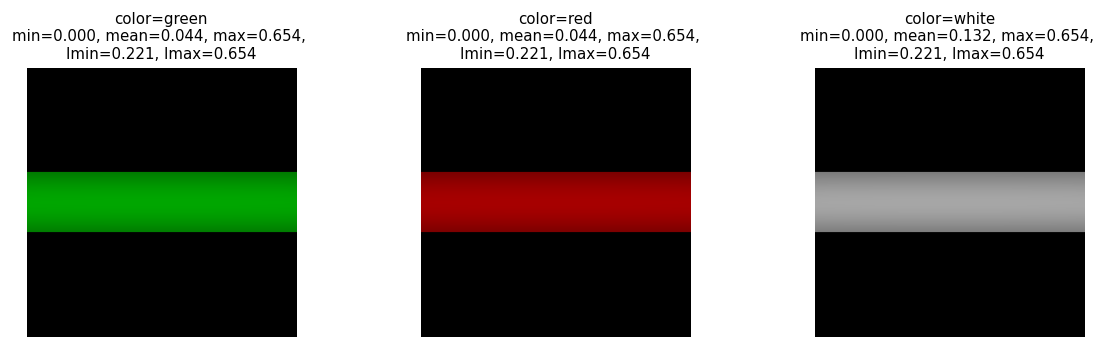

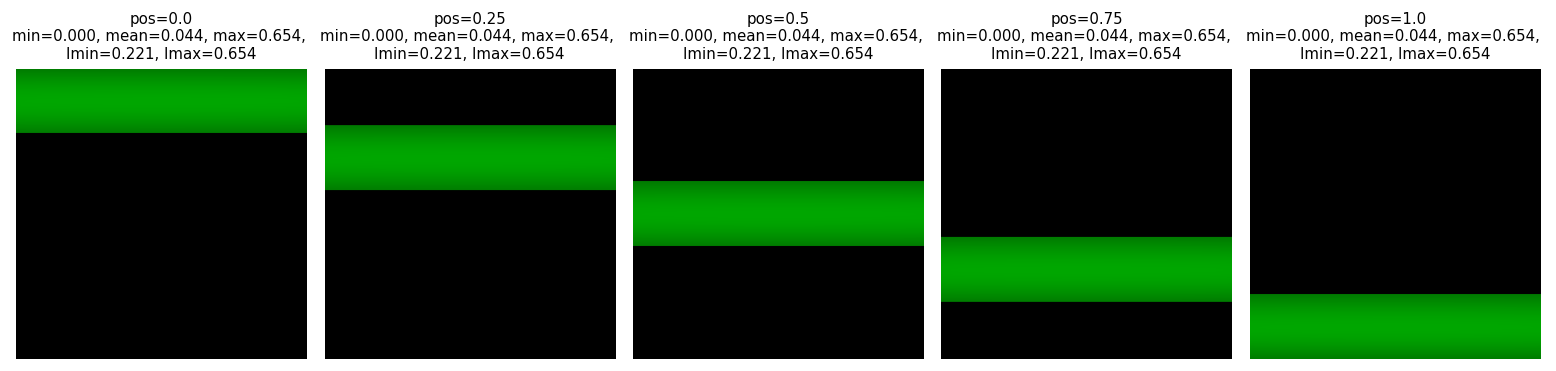

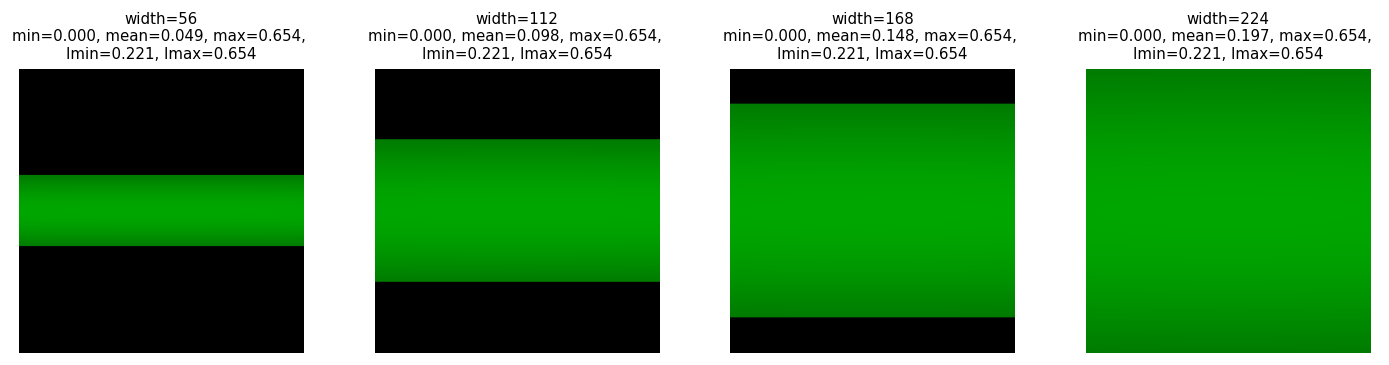

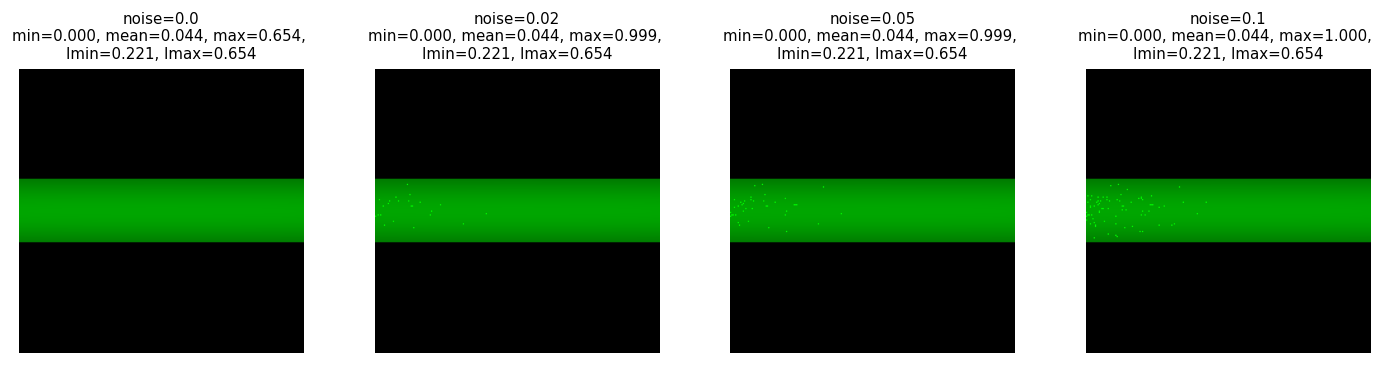

In [48]:
items = []
for color in ["green", "red", "white"]:
    t = make_trigger(base, isdetector=False, model=model_name, color=color, trigger_height=50)
    items.append((to_image(t), f"color={color}\n{summarize(t, base)}"))
show_grid(items, cols=3, figsize=(10, 3));

items = []
for position in [0.0, 0.25, 0.5, 0.75, 1.0]:
    t = make_trigger(base, isdetector=False, model=model_name, color="green", trigger_height=50, position=position)
    items.append((to_image(t), f"pos={position}\n{summarize(t, base)}"))
show_grid(items, cols=5, figsize=(13, 3));

items = []
for width in [56, 112, 168, 224]:
    t = make_trigger(base, isdetector=False, model=model_name, color="green", trigger_height=50, trigger_width=width)
    items.append((to_image(t), f"width={width}\n{summarize(t, base)}"))
show_grid(items, cols=4, figsize=(12, 3));

items = []
for noise in [0.0, 0.02, 0.05, 0.10]:
    torch.manual_seed(0)
    t = make_trigger(base, isdetector=False, model=model_name, color="green", trigger_height=50, noise_std=noise)
    items.append((to_image(t), f"noise={noise}\n{summarize(t, base)}"))
show_grid(items, cols=4, figsize=(12, 3));

## TA-C vs detector image size

The same generator emits 224x224 masks for TA-C and 640x640 masks for detector attacks.

Generated laser trigger tensor with shape: torch.Size([1, 3, 224, 224])
Generated laser trigger tensor with shape: torch.Size([1, 3, 640, 640])


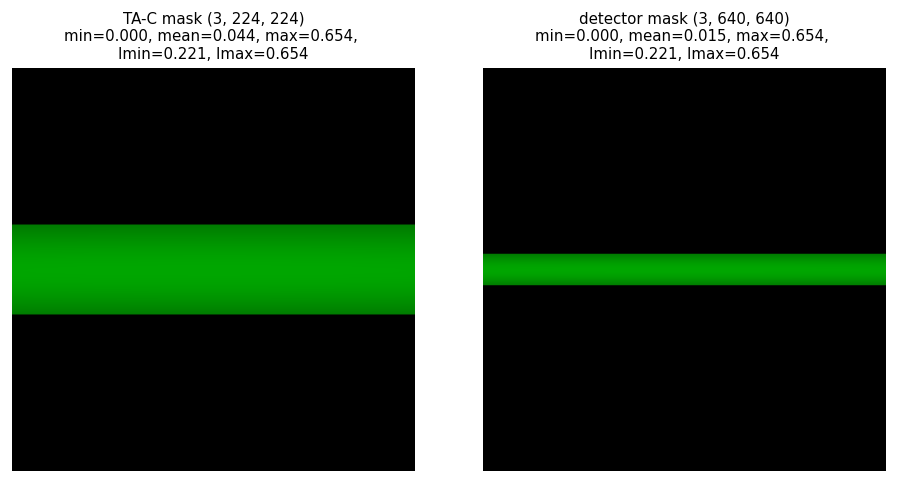

In [49]:
tac = make_trigger(base, isdetector=False, model=model_name, color="green", trigger_height=50)
det = make_trigger(base, isdetector=True, model=model_name, color="green", trigger_height=50)

show_grid([
    (to_image(tac), f"TA-C mask {tuple(tac.shape)}\n{summarize(tac, base)}"),
    (to_image(det), f"detector mask {tuple(det.shape)}\n{summarize(det, base)}"),
], cols=2, figsize=(8, 4));

## Overlay check

Training applies the trigger as additive light:

`imgp = clamp(imgn + trigger / 255, 0, 1)`

The cell below first keeps the neutral-gray overlay check, then shows the detector-sized laser stripe and its additive overlay on the selected COCO validation image.

Generated laser trigger tensor with shape: torch.Size([1, 3, 640, 640])


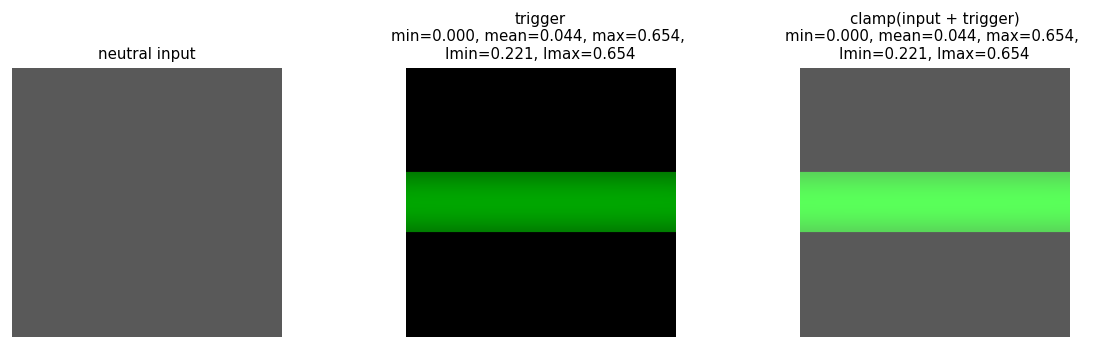

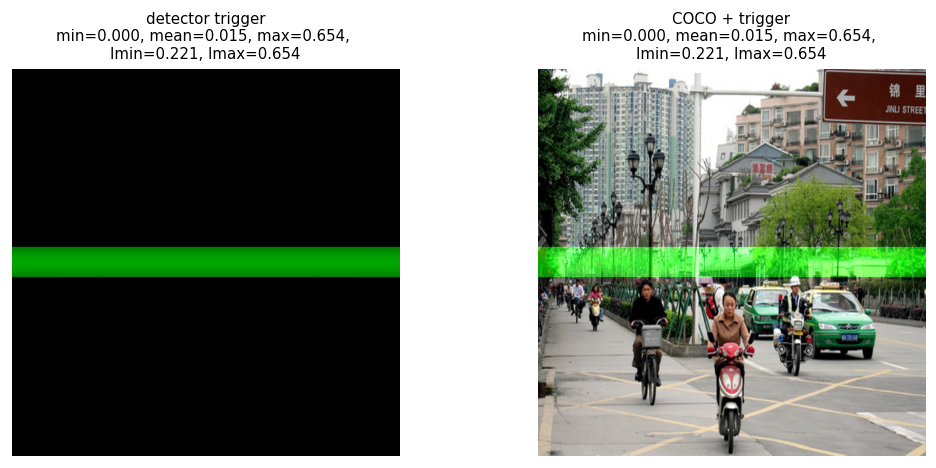

In [50]:
gray = torch.full_like(trigger, 0.35)
overlay = torch.clamp(gray + trigger / 255.0, 0.0, 1.0)

show_grid([
    (to_image(gray * 255.0), "neutral input"),
    (to_image(trigger), f"trigger\n{summarize(trigger, base)}"),
    (to_image(overlay * 255.0), f"clamp(input + trigger)\n{summarize(trigger, base)}"),
], cols=3, figsize=(10, 3));


def load_rgb_image(path):
    img = torch.as_tensor(plt.imread(str(path))).float()
    if img.max() > 1.0:
        img = img / 255.0
    if img.ndim == 2:
        img = img.unsqueeze(-1).repeat(1, 1, 3)
    if img.shape[-1] == 4:
        img = img[..., :3]
    return img.permute(2, 0, 1).contiguous()


def resize_chw(img, size):
    return F.interpolate(
        img.unsqueeze(0), size=size, mode="bilinear", align_corners=False
    )[0].clamp(0.0, 1.0)


coco_path = repo_root / "datasets/mscoco/val2014/COCO_val2014_000000581401.jpg"
coco_img = load_rgb_image(coco_path)
det_trigger = make_trigger(base, isdetector=True, model=model_name, color="green", trigger_height=50)
coco_resized = resize_chw(coco_img, det_trigger.shape[-2:])
coco_overlay = torch.clamp(coco_resized + det_trigger / 255.0, 0.0, 1.0)

show_grid([
    (to_image(det_trigger), f"detector trigger\n{summarize(det_trigger, base)}"),
    (to_image(coco_overlay * 255.0), f"COCO + trigger\n{summarize(det_trigger, base)}"),
], cols=2, figsize=(9, 4));